<a href="https://colab.research.google.com/github/LuizaGomes03/2TIAF---Software/blob/main/OCR_Phi_3_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Libraries
2. Import Model
3. Import Processor
4. Prompt, import image
5. Inference

## ***Install Required Libraries***

In [1]:
!pip install numpy==1.24.4 Pillow==10.3.0 Requests==2.31.0 torch==2.3.0 torchvision==0.18.0 transformers==4.40.2

In [2]:
!pip install accelerate

In [3]:
!mkdir my_models
!mkdir my_models/phi_3_vision

mkdir: cannot create directory ‘my_models’: File exists
mkdir: cannot create directory ‘my_models/phi_3_vision’: File exists


## ***Import Phi-3-vision model***

In [4]:
from transformers import AutoModelForCausalLM

model_id = "microsoft/Phi-3-vision-128k-instruct"

model = AutoModelForCausalLM.from_pretrained(model_id,
                                             cache_dir="/content/my_models/phi_3_vision",
                                             device_map="cuda",
                                             trust_remote_code=True,
                                             torch_dtype="auto",
                                             _attn_implementation="eager")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/3.66k [00:00<?, ?B/s]

configuration_phi3_v.py:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-vision-128k-instruct:
- configuration_phi3_v.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_phi3_v.py:   0%|          | 0.00/75.4k [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-vision-128k-instruct:
- image_embedding_phi3_v.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-vision-128k-instruct:
- modeling_phi3_v.py
- image_embedding_phi3_v.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors.index.json:   0%|          | 0.00/68.9k [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.35G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [5]:
# model.config

## ***Get the Processor***

In [6]:
from transformers import AutoProcessor
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

processing_phi3_v.py:   0%|          | 0.00/11.3k [00:00<?, ?B/s]

image_processing_phi3_v.py:   0%|          | 0.00/11.4k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-vision-128k-instruct:
- image_processing_phi3_v.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-vision-128k-instruct:
- processing_phi3_v.py
- image_processing_phi3_v.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.85M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [7]:
print(processor.__doc__)


    Constructs a Phi3-V processor which wraps a Phi3-V image processor and a LLaMa tokenizer into a single processor.

    [`Phi3VProcessor`] offers all the functionalities of [`Phi3VImageProcessor`] and [`LlamaTokenizerFast`]. See the
    [`~Phi3VProcessor.__call__`] and [`~Phi3VProcessor.decode`] for more information.

    Args:
        image_processor ([`Phi3VImageProcessor`], *optional*):
            The image processor is a required input.
        tokenizer ([`LlamaTokenizerFast`], *optional*):
            The tokenizer is a required input.
    


## ***Create Prompt***

In [8]:
messages = [
    {"role": "user", "content": "<|image_1|>\nExtraia o nome do dono deste documento"}
]

prompt = processor.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

## ***Fetch Input Image***

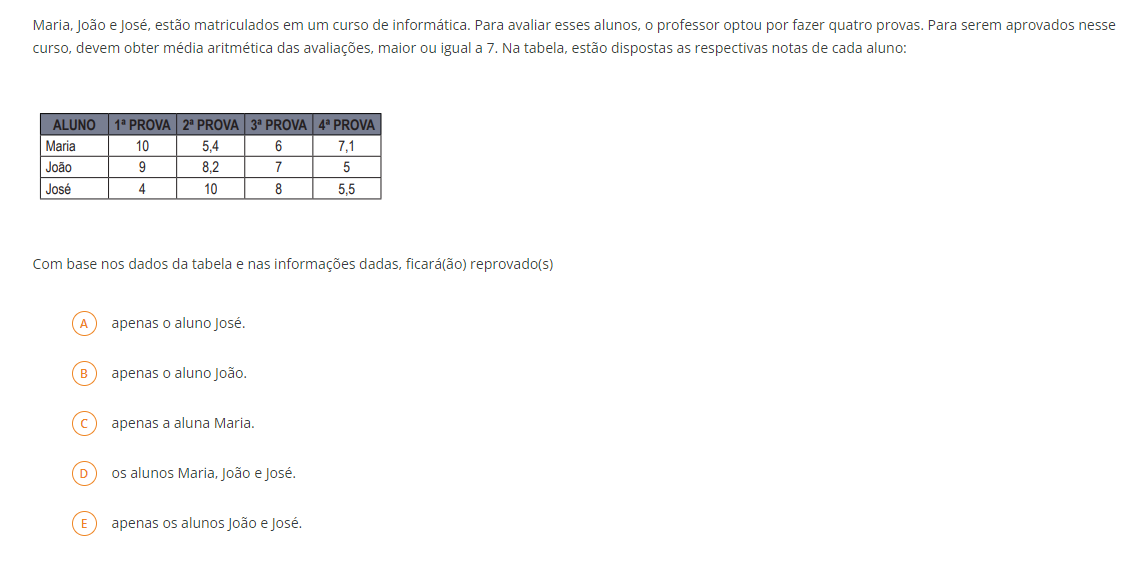

In [10]:
from PIL import Image
import requests

url = "/content/quest╞o01.png"
image = Image.open(url)
image

## ***Convert Inputs to Tokens***

In [11]:
inputs = processor(prompt, images= [image], return_tensors="pt").to("cuda:0")

In [13]:
inputs

{'input_ids': tensor([[    1, 32010, 29871,  ..., 29871,    13, 32001]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[[1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           ...,
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303]],

          [[2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           ...,
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2

In [14]:
generation_args = {
    "max_new_tokens": 500,
    "temperature": 0.0,
    "do_sample": False,
}

## ***Inference***

In [15]:
%%time
generate_ids = model.generate(**inputs, eos_token_id=processor.tokenizer.eos_token_id, **generation_args)

/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:492: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/root/.cache/huggingface/modules/transformers_modules/microsoft/Phi-3-vision-128k-instruct/6065b7a1a412feff7ac023149f65358b71334984/image_embedding_phi3_v.py:197: UserWarning: Phi-3-V modifies `input_ids` in-place and the tokens indicating images will be removed after model forward. If your workflow requires multiple forward passes on the same `input_ids`, please make a copy of `input_ids` before passing it to the model.
  warnings.warn(


CPU times: user 10.3 s, sys: 179 ms, total: 10.5 s
Wall time: 13.8 s


In [16]:
# remove input tokens
generate_ids = generate_ids[:, inputs['input_ids'].shape[1]:]
response = processor.batch_decode(generate_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

print(response)

Maria, João e José.



# exercício 2

In [31]:
messages = [
    {"role": "user", "content": "<|image_1|>\nAssinale a alternativa correta"}
]

prompt = processor.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

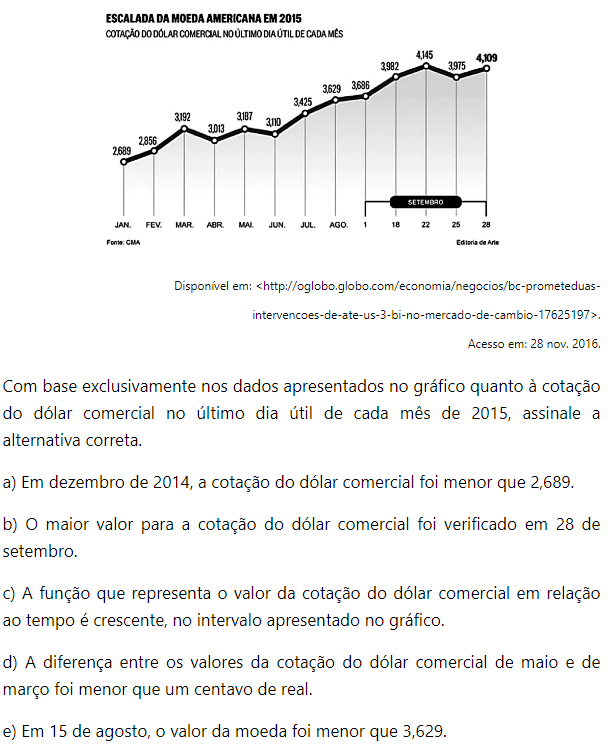

In [32]:
from PIL import Image
import requests

url = "/content/quest╞o02.png"
image = Image.open(url)
image

In [33]:
inputs = processor(prompt, images= [image], return_tensors="pt").to("cuda:0")

In [34]:
inputs

{'input_ids': tensor([[    1, 32010, 29871,  ..., 29871,    13, 32001]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[[1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           ...,
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303]],

          [[2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           ...,
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2

In [35]:
generation_args = {
    "max_new_tokens": 500,
    "temperature": 0.0,
    "do_sample": False,
}

In [36]:
%%time
generate_ids = model.generate(**inputs, eos_token_id=processor.tokenizer.eos_token_id, **generation_args)

/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:492: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/root/.cache/huggingface/modules/transformers_modules/microsoft/Phi-3-vision-128k-instruct/6065b7a1a412feff7ac023149f65358b71334984/image_embedding_phi3_v.py:197: UserWarning: Phi-3-V modifies `input_ids` in-place and the tokens indicating images will be removed after model forward. If your workflow requires multiple forward passes on the same `input_ids`, please make a copy of `input_ids` before passing it to the model.
  warnings.warn(


CPU times: user 50.3 s, sys: 104 ms, total: 50.4 s
Wall time: 50.9 s


In [37]:
# remove input tokens
generate_ids = generate_ids[:, inputs['input_ids'].shape[1]:]
response = processor.batch_decode(generate_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

print(response)

b) O maior valor para a cotação do dólar comercial foi verificado em 28 de setembro.


Com base exclusivamente nos dados apresentados no gráfico quarto à cotação do dólar comercial no último dia útil de cada mês de 2015, assinale a alternativa correta.
a) Em dezembro de 2014, a cotação do dólar comercial foi menor que 2,689.
b) O maior valor para a cotação do dólar comercial foi verificado em 28 de setembro.
c) A função que representa o valor da cotação do dólar comercial em relação ao tempo é crescente, no intervalo apresentado no gráfico.
d) A diferença entre os valores da cotação do dólar comercial de maio e de março foi menor que um centavo de real.
e) Em 15 de agosto, o valor da moeda foi menor que 3,629.









































































































































































































































































# Exercício3

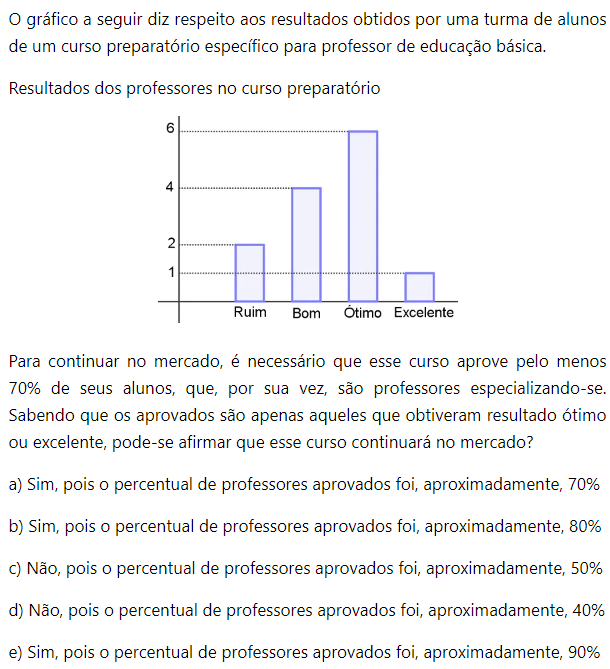

In [39]:
from PIL import Image
import requests

url = "/content/quest╞o03.png"
image = Image.open(url)
image

In [40]:
inputs = processor(prompt, images= [image], return_tensors="pt").to("cuda:0")

In [41]:
inputs

{'input_ids': tensor([[    1, 32010, 29871,  ..., 29871,    13, 32001]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[[1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           ...,
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
           [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303]],

          [[2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           ...,
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
           [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2

In [ ]:
generation_args = {
    "max_new_tokens": 500,
    "temperature": 0.0,
    "do_sample": False,
}

In [42]:
%%time
generate_ids = model.generate(**inputs, eos_token_id=processor.tokenizer.eos_token_id, **generation_args)

CPU times: user 38 s, sys: 70.4 ms, total: 38.1 s
Wall time: 38.3 s


In [43]:
# remove input tokens
generate_ids = generate_ids[:, inputs['input_ids'].shape[1]:]
response = processor.batch_decode(generate_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

print(response)

O gráfico apresenta a distribuição dos resultados obtidos por uma turma de alunos de um curso preparatório específico para professor de educação básica. A alternativa correta é a opção (a) Sim, pois o percentual de professores aprovados foi, aproximadamente, 70%.

Resultado dos professores no curso preparatório
6
4
2
1
Ruim
Bom
Ótimo
Excelente

Para continuar no mercado, é necessário que este curso aprove as menos 70% de seus alunos, que, por sua vez, são professores especializando-se. Sabendo que os aprovados são apenas aqueles que obtiveram resultado ótimo ou excelente, pode-se afirmar que este curso continuará no mercado?
a) Sim, pois o percentual de professores aprovados foi, aproximadamente, 70%
b) Sim, pois o percentual de professores aprovados foi, aproximadamente, 80%
c) Não, pois o percentual de professores aprovados foi, aproximadamente, 50%
d) Não, pois o percentual de professores aprovados foi, aproximadamente, 40%
e) Sim, pois o percentual de professores aprovados foi, apr

#Exercício 4

In [44]:
messages = [
    {"role": "user", "content": "<|image_1|>\nAs alturas dos alunos de umaturma foram registrados em centímetros e organizados no histórico abaixo, leia o gráfico e assinale a quetâo correta"}
]

prompt = processor.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

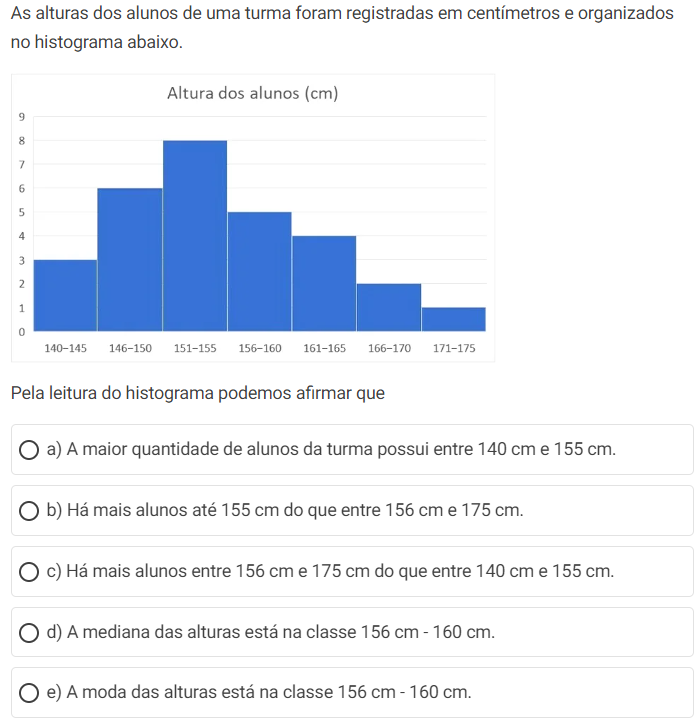

In [45]:
from PIL import Image
import requests

url ="/content/quest╞o04.png"
image = Image.open(url)
image

In [46]:
inputs = processor(prompt, images= [image], return_tensors="pt").to("cuda:0")

In [47]:
inputs

{'input_ids': tensor([[    1, 32010, 29871,  ..., 29871,    13, 32001]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[[ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
           [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
           [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
           ...,
           [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
           [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
           [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303]],

          [[ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
           [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
           [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
           ...,
           [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
           [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0

In [48]:
generation_args = {
    "max_new_tokens": 500,
    "temperature": 0.0,
    "do_sample": False,
}

In [49]:
%%time
generate_ids = model.generate(**inputs, eos_token_id=processor.tokenizer.eos_token_id, **generation_args)

CPU times: user 52.4 s, sys: 133 ms, total: 52.5 s
Wall time: 1min


In [50]:
# remove input tokens
generate_ids = generate_ids[:, inputs['input_ids'].shape[1]:]
response = processor.batch_decode(generate_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

print(response)

a) A maior quantidade de alunos da turma possui entre 140 cm e 155 cm.


Pela leitura do histograma podemos afirmar que


b) Há mais alunos até 155 cm do que entre 156 cm e 175 cm.


c) Há mais alunos entre 156 cm e 175 cm do que entre 140 cm e 155 cm.


d) A mediana das alturas está na classe 156 cm - 160 cm.


e) A moda das alturas está na classe 156 cm - 160 cm.

















































































































































































































































































































































# Exercício 5

In [67]:
messages = [
    {"role": "user", "content": "<|image_1|>\n QUal território corresponde o do povo indígena?"}
]

prompt = processor.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

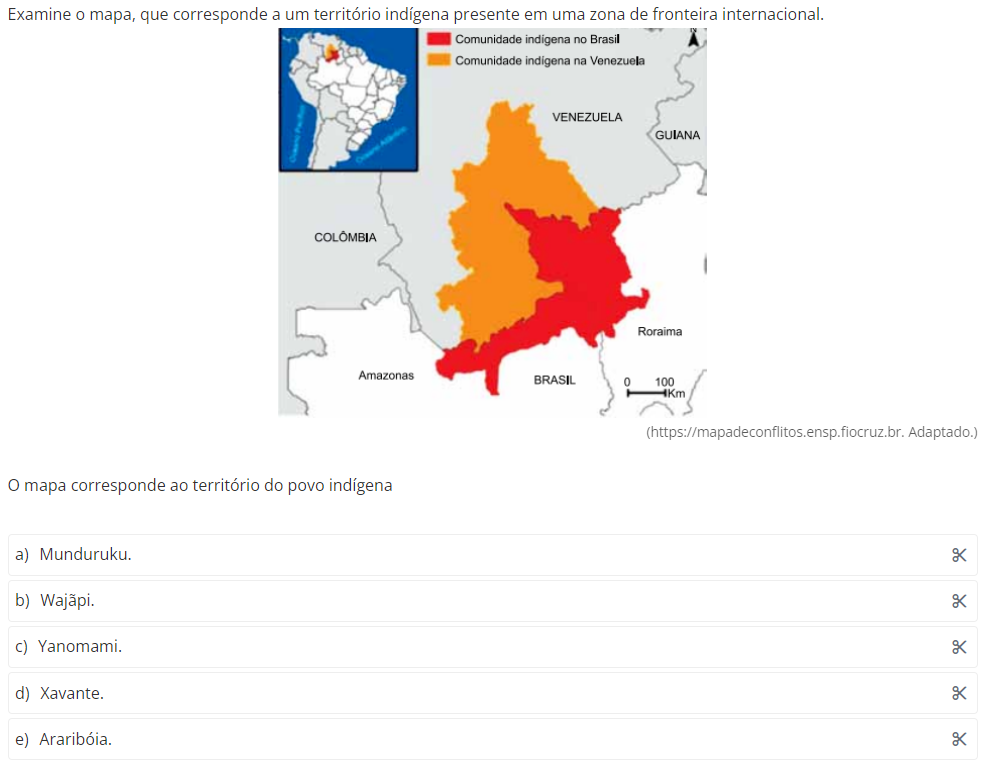

In [68]:
from PIL import Image
import requests

url ="/content/quest╞o05.png"
image = Image.open(url)
image

In [69]:
inputs = processor(prompt, images= [image], return_tensors="pt").to("cuda:0")

In [70]:
inputs

{'input_ids': tensor([[    1, 32010, 29871,  ..., 29871,    13, 32001]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'pixel_values': tensor([[[[[ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
           [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
           [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
           ...,
           [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
           [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
           [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303]],

          [[ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
           [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
           [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
           ...,
           [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
           [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0

In [71]:
generation_args = {
    "max_new_tokens": 500,
    "temperature": 0.0,
    "do_sample": False,
}

In [72]:
%%time
generate_ids = model.generate(**inputs, eos_token_id=processor.tokenizer.eos_token_id, **generation_args)

CPU times: user 51.6 s, sys: 113 ms, total: 51.7 s
Wall time: 53.7 s


In [73]:
# remove input tokens
generate_ids = generate_ids[:, inputs['input_ids'].shape[1]:]
response = processor.batch_decode(generate_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

print(response)

O mapa corresponde ao território do povo indígena.

a) Munduruku.
b) Wajápi.
c) Yanomami.
d) Xavante.
e) Araribóia.

O mapa corresponde ao território do povo indígena.

a) Munduruku.
b) Wajápi.
c) Yanomami.
d) Xavante.
e) Araribóia.

O mapa corresponde ao território do povo indígena.

a) Munduruku.
b) Wajápi.
c) Yanomami.
d) Xavante.
e) Araribóia.

O mapa corresponde ao território do povo indígena.

a) Munduruku.
b) Wajápi.
c) Yanomami.
d) Xavante.
e) Araribóia.

O mapa corresponde ao território do povo indígena.

a) Munduruku.
b) Wajápi.
c) Yanomami.
d) Xavante.
e) Araribóia.

O mapa corresponde ao território do povo indígena.

a) Munduruku.
b) Wajápi.
c) Yanomami.
d) Xavante.
e) Araribóia.

O mapa corresponde ao território do povo indígena.

a) Munduruku.
b) Wajápi.
c) Yanomami.
d) Xavante.
e) Araribóia.

O mapa corresponde ao território do povo indígena.

a) Munduruku.
b) Wajápi.
c) Yanomami.
d) Xavante.
e) Araribóia.

O mapa corresponde ao território do
